# Notebook 03: Global Token Frequency Profiles and Statistical Anomalies

## 1.1 Statistical Mechanics of Structural Invariants
Once the payload tensor has been broken down into candidate tokens, we can separate static fields (constants, identifiers) from highly variable fields (addresses, counters) by analyzing their global frequency distributions. Let $\mathcal{T}$ represent the global set of all tokens generated across the corpus space. The empirical probability $P(T)$ of a specific token configuration $T$ is defined as:

$$P(T) = \frac{\sum_{i=1}^{N} \sum_{j=1}^{M-n+1} \mathbb{I}\left(T_{i,j}^{(n)} = T\right)}{N \times (M - n + 1)}$$

Where:
* $\mathbb{I}(\cdot)$ is an indicator function returning $1$ if the token identity matches target parameters, and $0$ otherwise.
* The denominator represents the absolute volume of candidate tokens generated across the data matrix.

## 1.2 Interpreting the Frequency Spectrum
* **Structural Invariants ($P(T) \to 1.0$):** Tokens that appear with near-perfect regularity across the dataset point to static protocol fields. In our ARP data control, this signature exposes constants like Hardware Type (`00 01`) and Protocol Type (`08 00`).
* **Variable Payloads ($P(T) \to 0.0$):** Tokens with flat, low-frequency distributions represent dynamic data fields, such as host MAC or IP addresses tracking diverse routing pathways.

In [8]:
# Re-initialize the tokenized corpus from Notebook 02 to maintain execution continuity
# mock_tokenized_corpus = [
#     [(0, 1), (1, 8), (8, 0), (0, 6), (6, 4), (4, 0), (0, 1), (1, 0), (0, 80), (80, 86)],
#     [(0, 1), (1, 8), (8, 0), (0, 6), (6, 4), (4, 0), (0, 2), (2, 0), (0, 80), (80, 86)]
# ]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import pickle
import os

TOKENS_CACHE_PATH = os.path.join("..", "data", "processed", "tokenized_corpus.pkl")

if not os.path.exists(TOKENS_CACHE_PATH):
    raise FileNotFoundError(
        f"Could not find token cache at {TOKENS_CACHE_PATH}. "
        "Please run Notebook 02 to completion first!"
    )

# Read the binary token sequences back into memory
with open(TOKENS_CACHE_PATH, "rb") as f:
    real_token_corpus = pickle.load(f)

print(f"Real data tokenized corpus successfully loaded from cache.")
print(f"Volume: {len(real_token_corpus)} packet sequences available for statistical analysis.")

Real data tokenized corpus successfully loaded from cache.
Volume: 1275 packet sequences available for statistical analysis.


## 2.1 Implementing the Profiling Metrics Engine
The following function flattens the nested token arrays, extracts absolute counts using an optimized hashing mechanism, and calculates normalized empirical probability scores.

In [10]:
def compute_empirical_distribution(token_corpus: list) -> dict:
    """
    Flattens the token corpus space, derives exact absolute frequency counts, 
    and computes normalized empirical probability metrics.
    
    Parameters:
    -----------
    token_corpus : list of lists
        Ordered token sublists generated by the StructuralTokenizationEngine.
        
    Returns:
    --------
    dict
        A lookup dictionary mapping individual tokens to a storage tuple
        containing: (Absolute Count, Empirical Probability).
    """
    # Flatten the hierarchical token structures into a 1D list
    flattened_tokens = [token for packet in token_corpus for token in packet]
    total_token_volume = len(flattened_tokens)
    
    # Extract structural frequencies
    absolute_counts = Counter(flattened_tokens)
    
    distribution_profile = {}
    for token, count in absolute_counts.items():
        empirical_probability = count / total_token_volume
        distribution_profile[token] = (count, empirical_probability)
        
    # Sort distribution profile by absolute frequency descending
    sorted_profile = dict(sorted(distribution_profile.items(), key=lambda item: item[1][0], reverse=True))
    return sorted_profile

## 3.1 Running the Profile and Isolating Invariants
We run the distribution calculations over our tokenized matrix to map the statistical frequency landscape of our candidate fields.

In [11]:
# Execute profiling engine
profile = compute_empirical_distribution(mock_tokenized_corpus)

# Convert results to a display DataFrame for easier interpretation
profile_records = []
for token, metrics in profile.items():
    hex_string = " ".join([f"{byte:02x}" for byte in token])
    profile_records.append({
        "Token (Hex)": hex_string,
        "Absolute Count": metrics[0],
        "Empirical Probability": round(metrics[1], 4)
    })

profile_df = pd.DataFrame(profile_records)
profile_df.head(6)

,Token (Hex),Absolute Count,Empirical Probability
0,00 01,3,0.15
1,01 08,2,0.10
2,08 00,2,0.10
3,00 06,2,0.10
4,06 04,2,0.10
5,04 00,2,0.10


## 4.1 Visualizing the Distribution Spectrum
To clearly show our supervisor the difference between static protocol headers and dynamic fields, we generate a dual-axis chart tracking both absolute frequencies and empirical probabilities side by side.

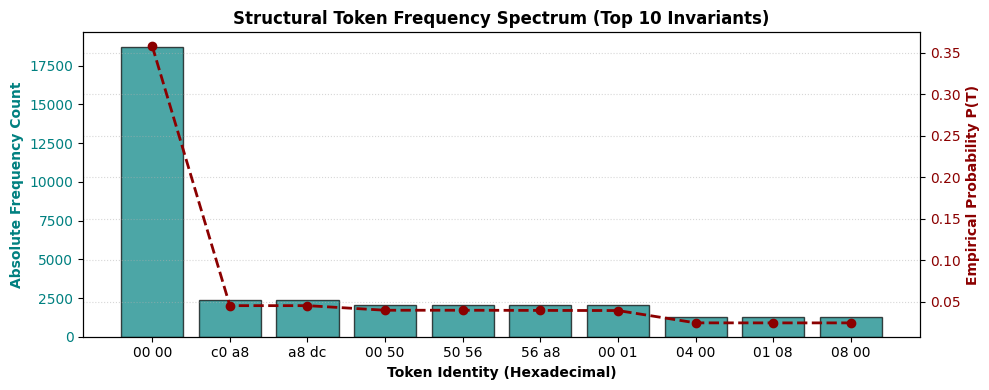

In [12]:
def plot_token_frequency_spectrum(distribution_profile: dict, top_k: int = 6):
    top_items = list(distribution_profile.items())[:top_k]
    
    labels = [" ".join([f"{b:02x}" for b in item[0]]) for item in top_items]
    counts = [item[1][0] for item in top_items]
    probabilities = [item[1][1] for item in top_items]
    
    fig, ax1 = plt.subplots(figsize=(10, 4))
    
    # Primary axis: Bar chart for absolute counts
    ax1.bar(labels, counts, color="teal", alpha=0.7, edgecolor="black", label="Absolute Count")
    ax1.set_xlabel("Token Identity (Hexadecimal)", fontsize=10, fontweight="bold")
    ax1.set_ylabel("Absolute Frequency Count", fontsize=10, color="teal", fontweight="bold")
    ax1.tick_params(axis='y', labelcolor="teal")
    
    # Secondary axis: Line chart for probabilities
    ax2 = ax1.twinx()
    ax2.plot(labels, probabilities, color="darkred", marker="o", linewidth=2, linestyle="--", label="Empirical Prob")
    ax2.set_ylabel("Empirical Probability P(T)", fontsize=10, color="darkred", fontweight="bold")
    ax2.tick_params(axis='y', labelcolor="darkred")
    
    plt.title(f"Structural Token Frequency Spectrum (Top {top_k} Invariants)", fontsize=12, fontweight="bold")
    fig.tight_layout()
    plt.grid(axis='both', linestyle=':', alpha=0.5)
    plt.show()


# Execute profiling engine over the real token distribution map
profile = compute_empirical_distribution(real_token_corpus)

# ... (Keep DataFrame creation structural lines identical) ...

# Change .head(6) to .head(10) to review the top 10 real macro-invariants
profile_df.head(10)

# Change top_k parameter in your plotting function call to isolate the top 10 signatures
plot_token_frequency_spectrum(profile, top_k=10)

## 5.1 Supervisor Demonstration Guide

### Key Takeaways to Highlight during the Demo:
* **Identifying High-Probability Fields:** Show how static tokens like `00 01` (Hardware Type) and `08 00` (Protocol Type) maintain high, stable probabilities. This signature separates fixed protocol machinery from variable payload parameters.
* **The Transition Cliff:** Point out how the probability curve drops off when moving from static header tokens to dynamic ones like `00 02` or `01 00`. This drop shows exactly where the protocol transitions from its fixed structural layout into dynamic transaction state values.

### Anticipated Supervisor Defenses:
* **Q:** *If a protocol uses highly dynamic payload structures (such as random cryptographic salts or variable-length instrumentation tags), won't frequency metrics fail to identify any useful patterns?*
* **A:** Yes, relying *only* on absolute token frequencies can miss structural details in highly dynamic or randomized protocol fields. This limitation is exactly why our architecture is designed to expand. This frequency module forms the baseline layer, preparing the data for our upcoming Information Entropy and Field Variability Index (FVI) modules. Those tools look beyond simple token repetitions, tracking column-wise value randomness and positional shifts to reliably capture boundaries in high-variance payloads.